# **2026 EDA for Johor State Properties in Malaysia**

In [1]:
import pandas as pd 
import numpy as np
import missingno as msno 
import matplotlib.pyplot as plt 
import seaborn as sns

**Load the dataset:**

In [2]:
train_file_path = "../input/datasets/sulaimantajuddin/johor-property-transaction-price/Open Transaction Data (1).csv"
df = pd.read_csv(train_file_path, sep='\t')
print("Full train dataset shape is {}".format(df.shape))

Full train dataset shape is (45021, 14)


**Analyze raw data:**

In [3]:
df.head()

,Property Type,District,Mukim,Scheme Name/Area,Road Name,"Month, Year of Transaction Date",Tenure,Land/Parcel Area,Unit,Main Floor Area,Unit,Unit Level,Transaction Price,Unnamed: 13
0,1 - 1 1/2 Storey Semi-Detached,Johor Bahru,Bandar Johor Bahru,FRESH BREEZE,JLN CHANTEK,December 2021,Freehold,472.23,sq.m,89,sq.m,,"RM700,000.00",NaN
1,1 - 1 1/2 Storey Semi-Detached,Johor Bahru,Bandar Johor Bahru,FRESH BREEZE,JLN MAS,July 2022,Freehold,348.19,sq.m,89,sq.m,,"RM750,000.00",NaN
2,1 - 1 1/2 Storey Semi-Detached,Johor Bahru,Bandar Johor Bahru,FRESH BREEZE,JLN SEPOI,January 2025,Freehold,384.43,sq.m,83,sq.m,,"RM920,000.00",NaN
3,1 - 1 1/2 Storey Semi-Detached,Johor Bahru,Bandar Johor Bahru,KAW ABDUL SAMAD/MARIAMAH,JLN ABDUL SAMAD / LRG 2B,August 2024,Freehold,416.29,sq.m,128,sq.m,,"RM600,000.00",NaN
4,1 - 1 1/2 Storey Semi-Detached,Johor Bahru,Bandar Johor Bahru,KAW ABDUL SAMAD/MARIAMAH,JLN DAPAT,September 2024,Freehold,645.28,sq.m,175,sq.m,,"RM900,000.00",NaN


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45021 entries, 0 to 45020
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Property Type                    45021 non-null  object 
 1   District                         45021 non-null  object 
 2   Mukim                            45021 non-null  object 
 3   Scheme Name/Area                 45021 non-null  object 
 4   Road Name                        45021 non-null  object 
 5   Month, Year of Transaction Date  45021 non-null  object 
 6   Tenure                           45021 non-null  object 
 7   Land/Parcel Area                 45021 non-null  object 
 8   Unit                             45021 non-null  object 
 9   Main Floor Area                  45021 non-null  object 
 10  Unit                             45021 non-null  object 
 11  Unit Level                       45021 non-null  object 
 12  Transaction Price 

<Axes: >

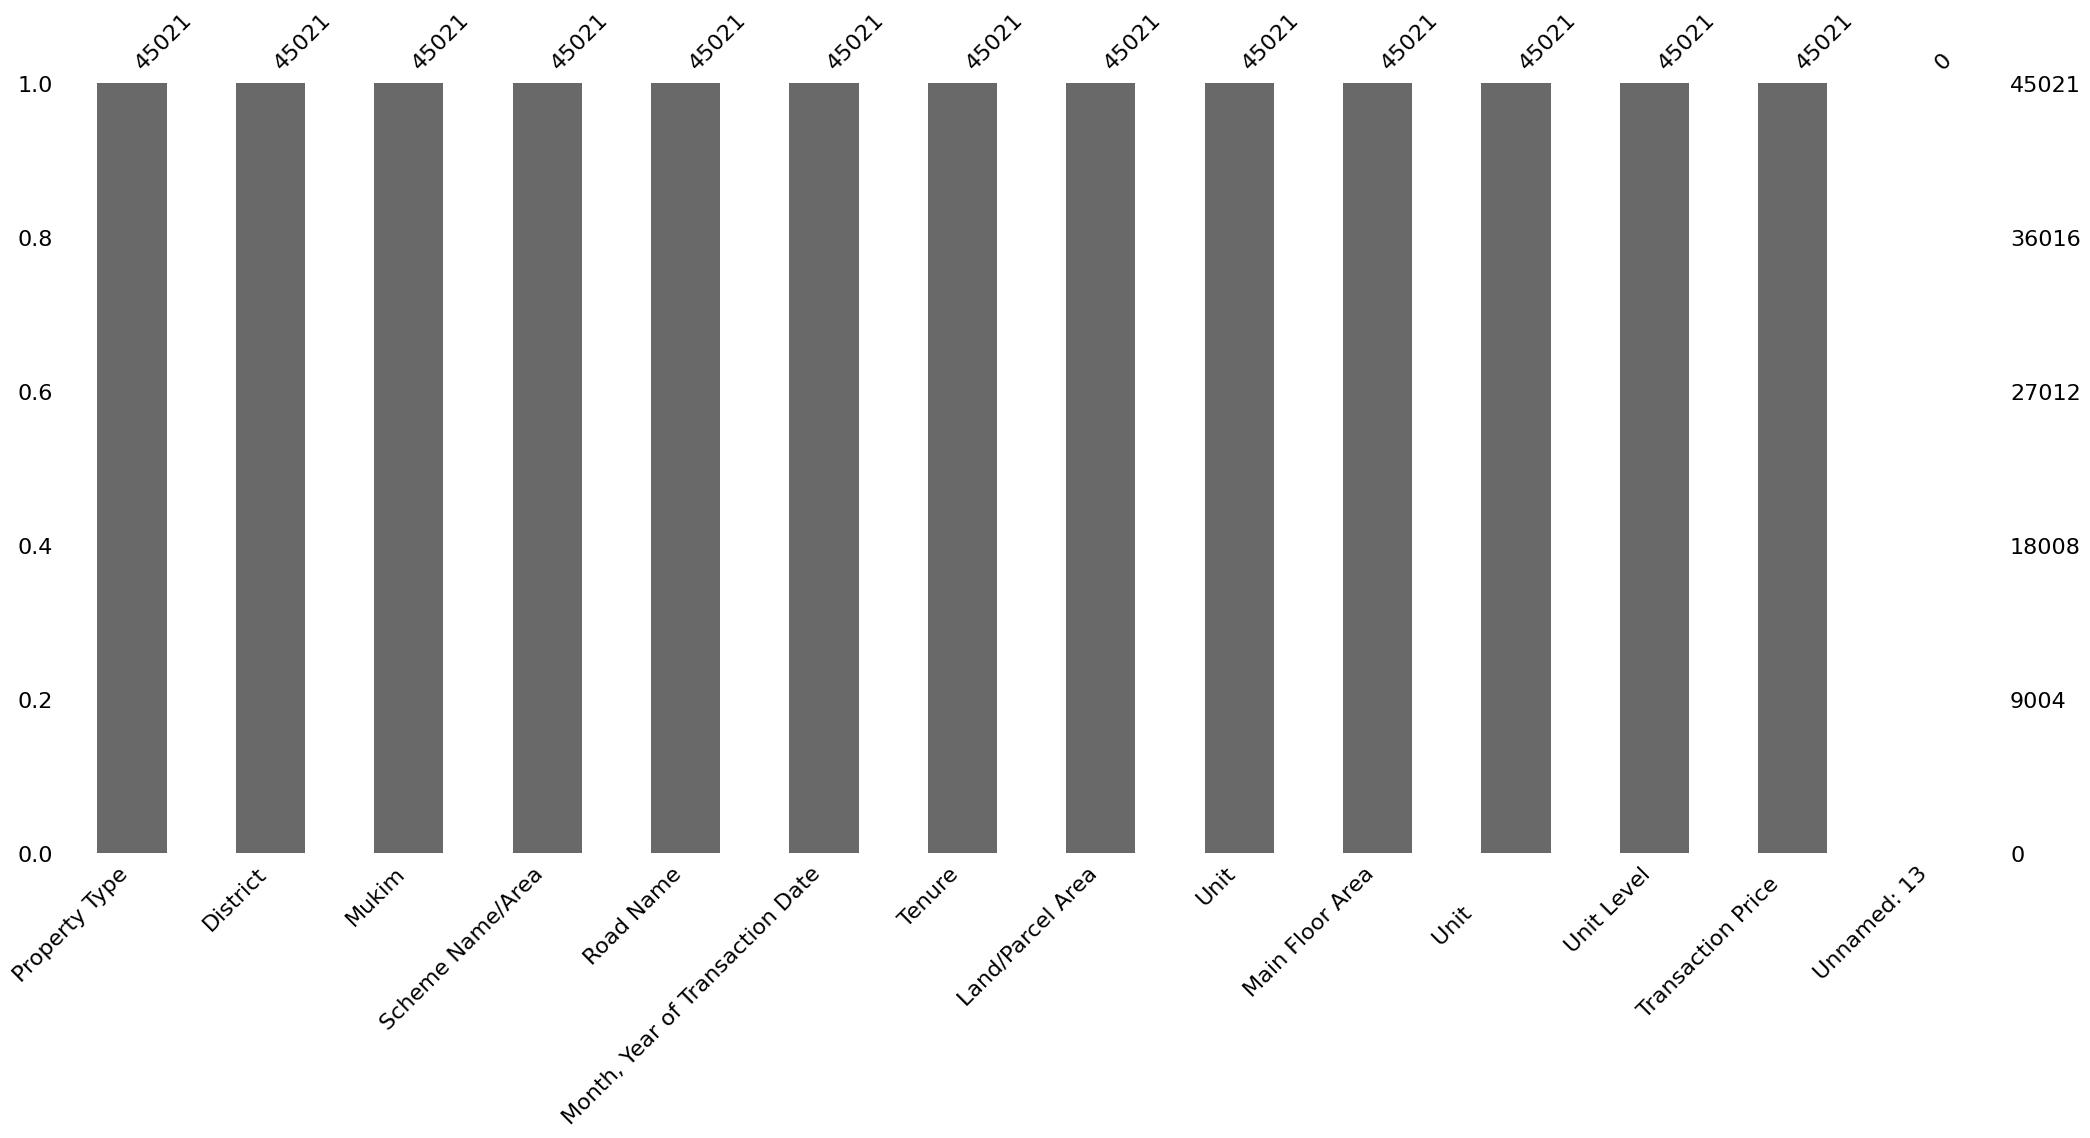

In [5]:
msno.bar(df)

In [6]:
print("\nExisting column :\n " + f"{df.columns.tolist()}") # inspect column name, view any whitespace


Existing column :
 ['Property Type', 'District', 'Mukim', 'Scheme Name/Area', 'Road Name', 'Month, Year of Transaction Date', 'Tenure', 'Land/Parcel Area', 'Unit', 'Main Floor Area', 'Unit        ', 'Unit Level', 'Transaction Price  ', 'Unnamed: 13']


In [7]:
for i in df.columns: # checking total null values/NaN in a column
    print(i," : ",df[i].isnull().sum()) # OR print(i," : ",df[i].isna().sum())

Property Type  :  0
District  :  0
Mukim  :  0
Scheme Name/Area  :  0
Road Name  :  0
Month, Year of Transaction Date  :  0
Tenure  :  0
Land/Parcel Area  :  0
Unit  :  0
Main Floor Area  :  0
Unit          :  0
Unit Level  :  0
Transaction Price    :  0
Unnamed: 13  :  45021


**Data wrangling:**

In [8]:
df.columns = df.columns.str.strip() # remove leading and trailing whitespace
print("\nExisting column :\n " + f"{df.columns.tolist()}") # inspect column after remove leading and trailing whitespaceqq


Existing column :
 ['Property Type', 'District', 'Mukim', 'Scheme Name/Area', 'Road Name', 'Month, Year of Transaction Date', 'Tenure', 'Land/Parcel Area', 'Unit', 'Main Floor Area', 'Unit', 'Unit Level', 'Transaction Price', 'Unnamed: 13']


In [9]:
for i in df.columns: # checking total null values/NaN in a column
    print(i," : ",df[i].isnull().sum()) # OR print(i," : ",df[i].isna().sum())

Property Type  :  0
District  :  0
Mukim  :  0
Scheme Name/Area  :  0
Road Name  :  0
Month, Year of Transaction Date  :  0
Tenure  :  0
Land/Parcel Area  :  0
Unit  :  Unit    0
Unit    0
dtype: int64
Main Floor Area  :  0
Unit  :  Unit    0
Unit    0
dtype: int64
Unit Level  :  0
Transaction Price  :  0
Unnamed: 13  :  45021


In [10]:
df = df.dropna(axis=1, how='all') # remove the entire column only if all values are NaN and print the output after removed NaN column:
print("\nResult after remove NaN column :\n"+ f"{df.columns.tolist()}")


Result after remove NaN column :
['Property Type', 'District', 'Mukim', 'Scheme Name/Area', 'Road Name', 'Month, Year of Transaction Date', 'Tenure', 'Land/Parcel Area', 'Unit', 'Main Floor Area', 'Unit', 'Unit Level', 'Transaction Price']


For this dataset we will delete unwanted column including Land/Parcel Area and others that we might see unfit

In [11]:
df = df.drop(columns=['District','Land/Parcel Area','Unit','Unit Level']) 

Clean and converting:

In [12]:
# Clean and convert 'Transaction Price' to numeric
df['Transaction Price'] = df['Transaction Price'].str.replace('RM', '', regex=False)
df['Transaction Price'] = df['Transaction Price'].str.replace(',', '', regex=False).astype(float)

print(df['Main Floor Area'].unique(),'\n')
print(df['Main Floor Area'][df['Main Floor Area'] == ''],'\n')  # find empty strings

# Clean and convert 'Main Floor Area' to numeric
df['Main Floor Area'] = df['Main Floor Area'].str.replace('-', '', regex=False)
df['Main Floor Area'] = df['Main Floor Area'].str.replace(',', '', regex=False).replace('', np.nan).astype(float)

['89' '83' '128' '175' '98' '102' '101' '112' '125' '116' '148' '141'
 '190' '97' '100' '127' '84' '138' '94' '104' '130' '174' '73' '117' '183'
 '99' '85' '110' '93' '86' '115' '126' '87' '106' '256' '107' '103' '131'
 '195' '71' '451' '91' '139' '236' '142' '96' '259' '120' '88' '124' '92'
 '68' '78' '77' '111' '90' '210' '135' '79' '189' '46' '59' '52' '60' '51'
 '63' '69' '55' '167' '76' '72' '143' '105' '114' '133' '57' '118' '64'
 '67' '81' '80' '82' '75' '70' '134' '132' '159' '121' '146' '65' '74'
 '61' '156' '145' '95' '123' '154' '181' '186' '108' '66' '62' '140' '144'
 '45' '137' '193' '53' '58' '109' '163' '184' '162' '157' '119' '230'
 '180' '48' '129' '1,359' '122' '49' '155' '153' '225' '158' '177' '113'
 '151' '164' '170' '185' '334' '172' '214' '201' '228' '194' '235' '152'
 '200' '320' '233' '223' '293' '178' '237' '314' '212' '306' '372' '312'
 '216' '265' '226' '242' '203' '198' '313' '279' '247' '275' '520' '510'
 '353' '582' '370' '580' '192' '208' '234' '494' '19

In [13]:
for i in df.columns: # checking total null values/NaN in a column
    print(i," : ",df[i].isnull().sum()) # OR print(i," : ",df[i].isna().sum())

Property Type  :  0
Mukim  :  0
Scheme Name/Area  :  0
Road Name  :  0
Month, Year of Transaction Date  :  0
Tenure  :  0
Main Floor Area  :  10552
Transaction Price  :  0


**Outlier detection:**

In [14]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Main Floor Area,34469.0,137.953204,66.619154,0.0,85.0,133.0,169.0,1875.0
Transaction Price,45021.0,578856.844584,425388.563336,22000.0,350000.0,498000.0,692000.0,12288000.0


For Transaction Price column: 
 1) It is hard to detect outliers for transaction price since the prices were volatile. Some transacted property in reality are overprice
 2) Some of the overprice property sits outside the whiskers
 3) Johor Bahru was well known for property price bias and segmentation

**Analyze clean data:**

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45021 entries, 0 to 45020
Data columns (total 8 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Property Type                    45021 non-null  object 
 1   Mukim                            45021 non-null  object 
 2   Scheme Name/Area                 45021 non-null  object 
 3   Road Name                        45021 non-null  object 
 4   Month, Year of Transaction Date  45021 non-null  object 
 5   Tenure                           45021 non-null  object 
 6   Main Floor Area                  34469 non-null  float64
 7   Transaction Price                45021 non-null  float64
dtypes: float64(2), object(6)
memory usage: 2.7+ MB


<Axes: >

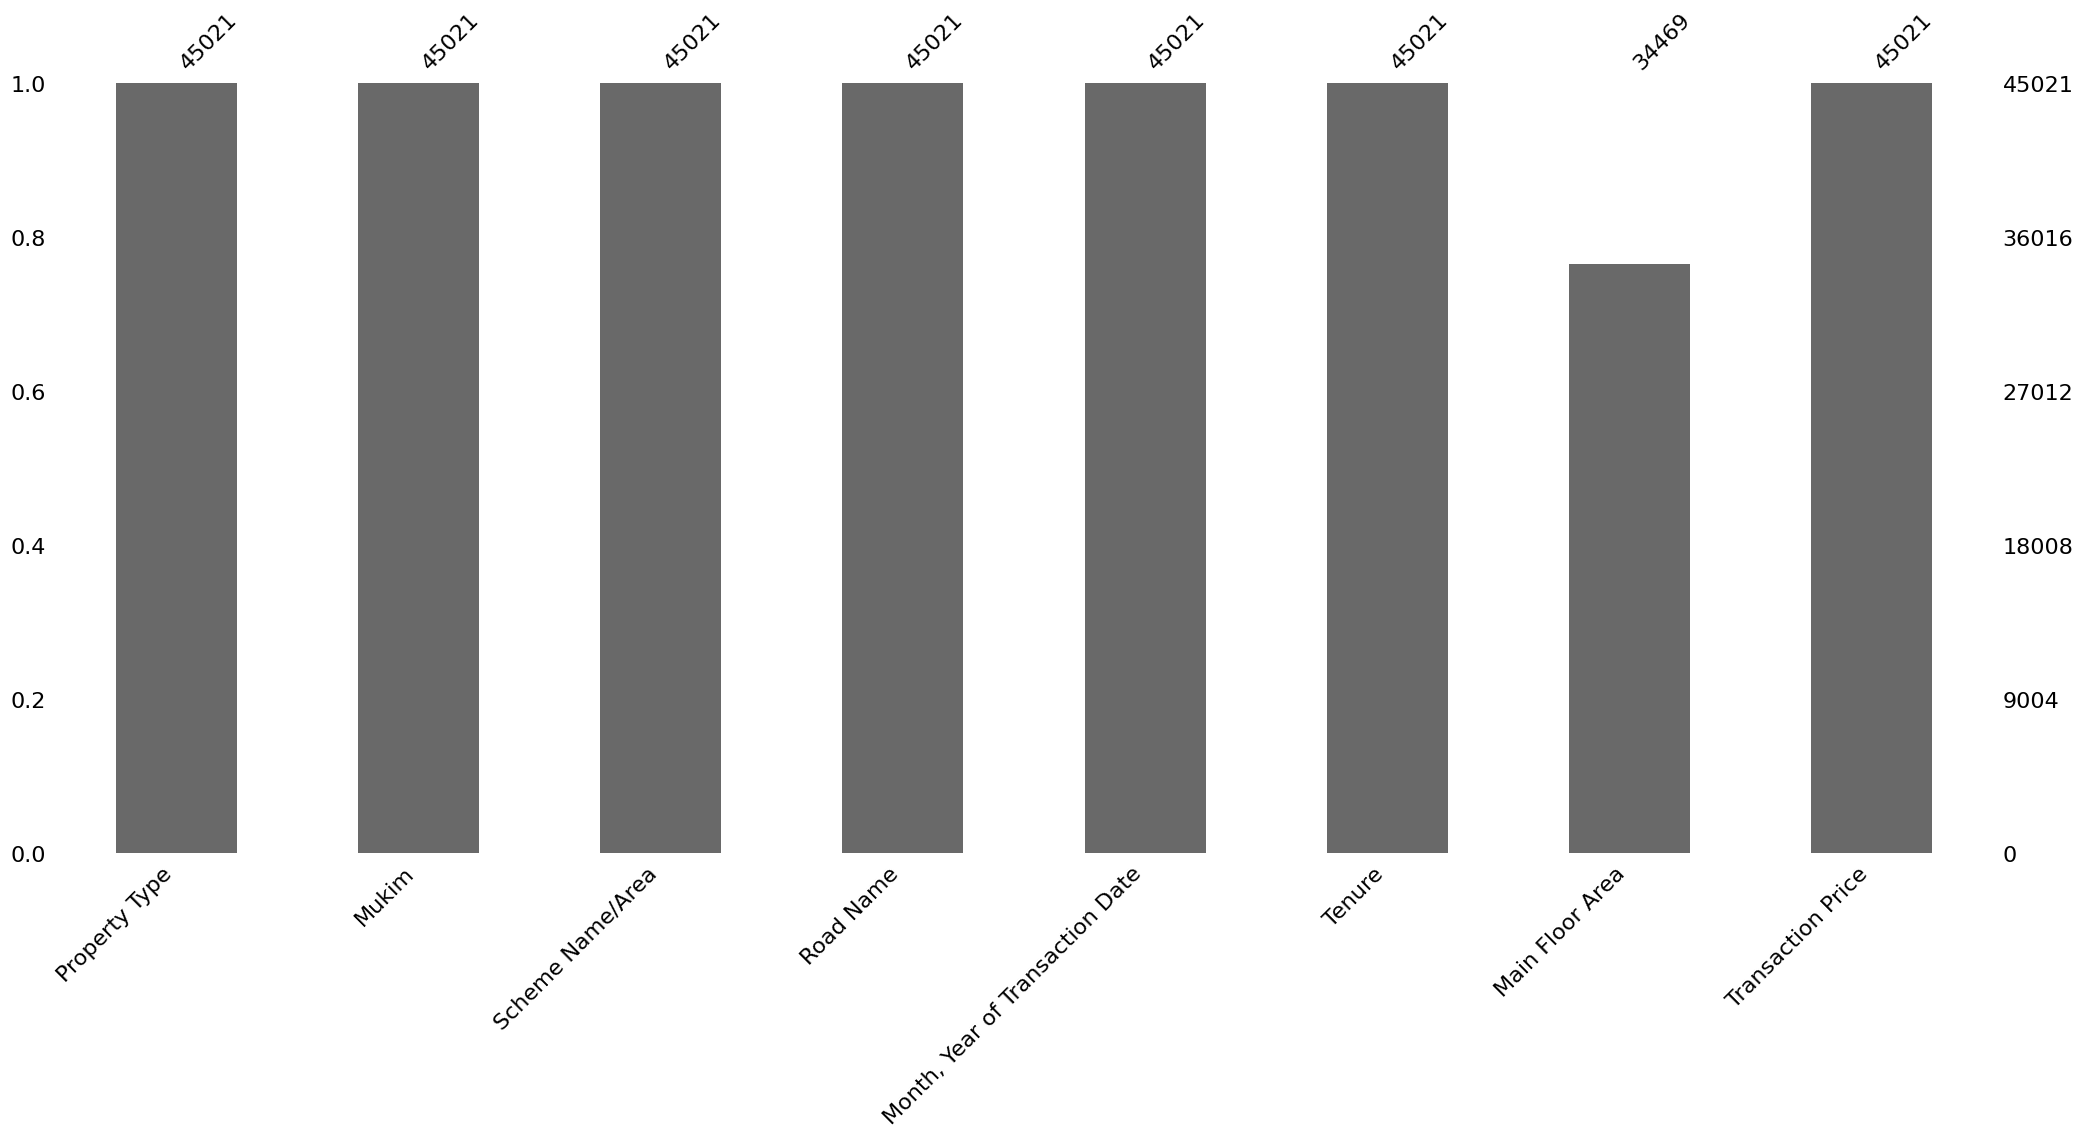

In [16]:
msno.bar(df)

Missing certain data for Main Floor Area column due to null values/NaN

<Axes: >

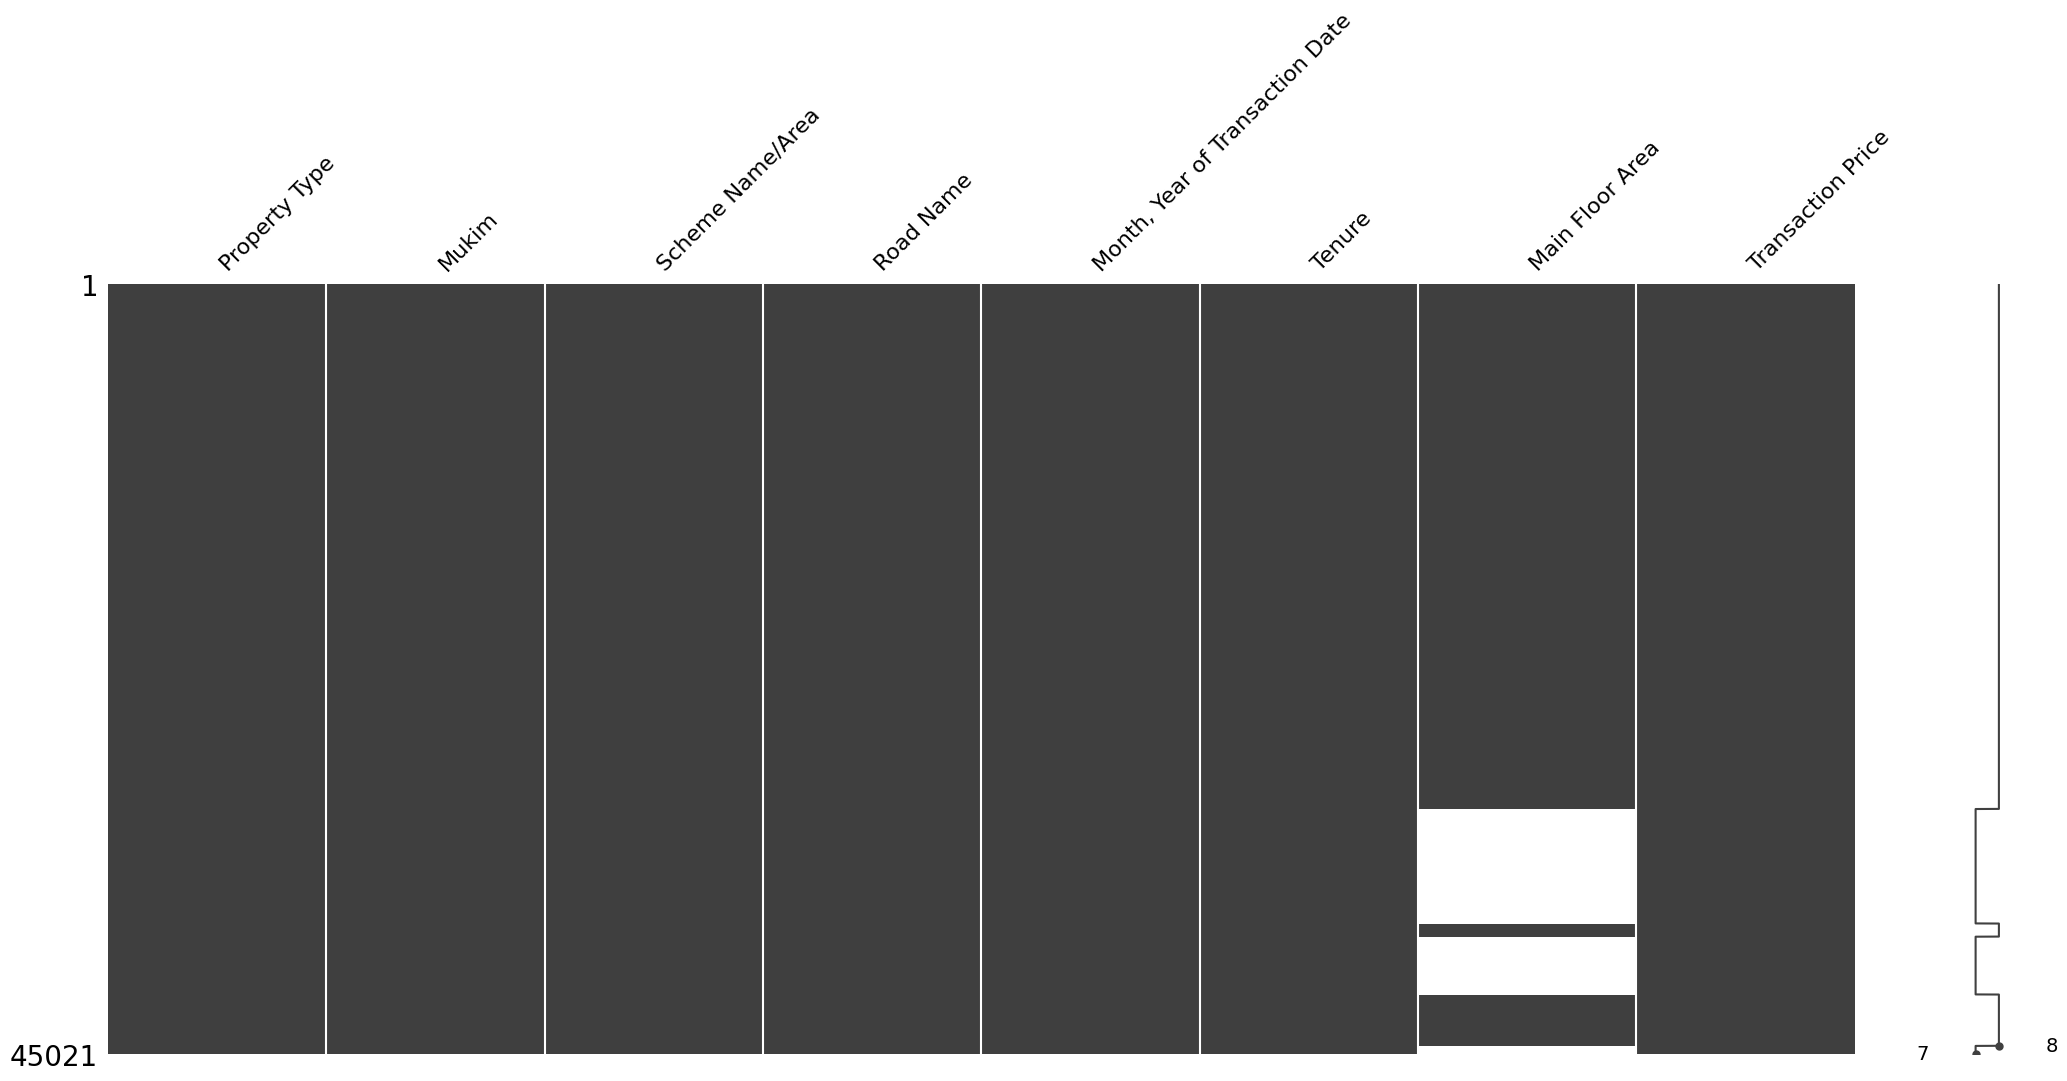

In [17]:
msno.matrix(df)  # visualizing missing numeric data with Matrix plot (missingno library)

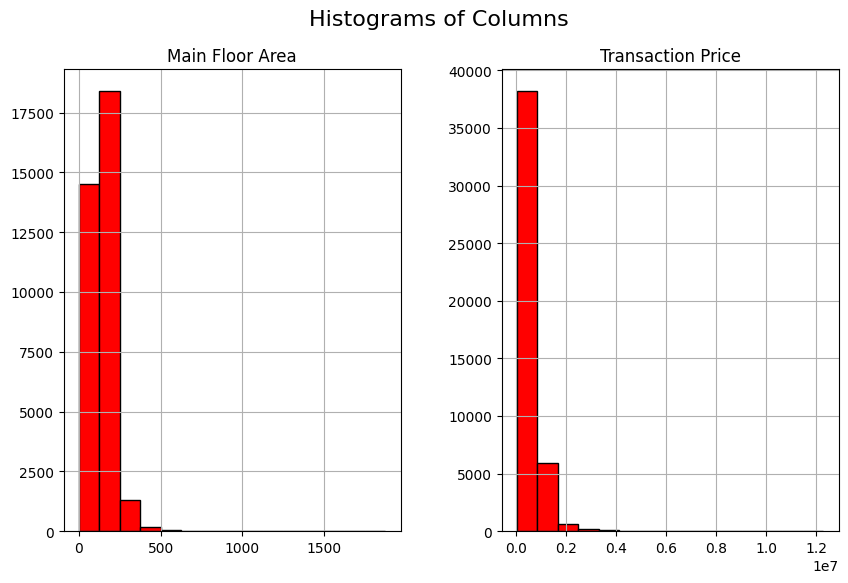

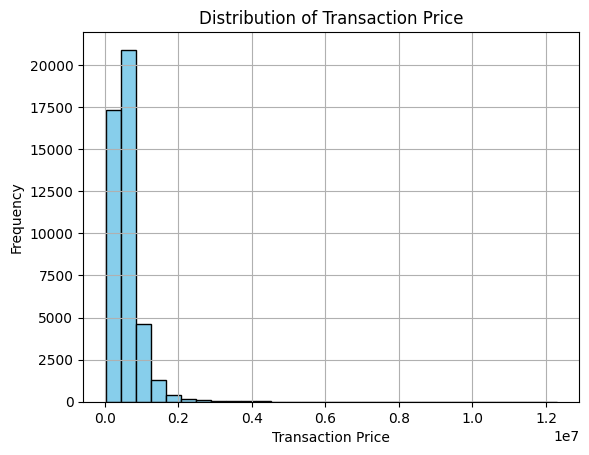

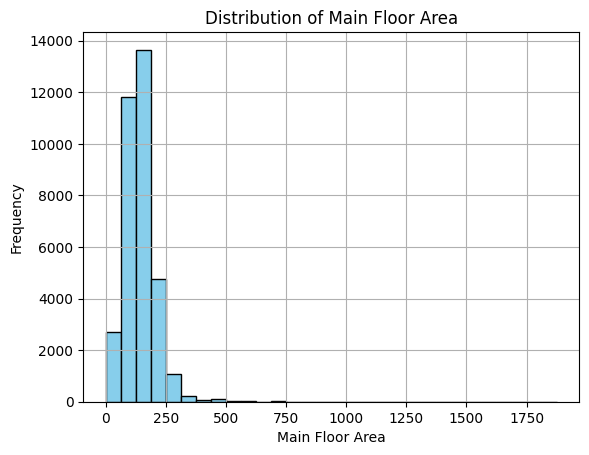

In [18]:
# Overall Histogram
df.hist(bins=15, figsize=(10, 6), color='red', edgecolor='black')
plt.suptitle('Histograms of Columns', fontsize=16)
plt.subplots_adjust(hspace=0.5)
plt.show()

print('\n\n')

# Transaction Price Histogram
plt.hist((df['Transaction Price']), bins=30, color='skyblue', edgecolor='black')
plt.title('Distribution of Transaction Price')
plt.xlabel('Transaction Price')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# Main Floor Area Histogram
plt.hist((df['Main Floor Area']), bins=30, color='skyblue', edgecolor='black')
plt.title('Distribution of Main Floor Area')
plt.xlabel('Main Floor Area')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

Replace missing data for Main Floor Area column by imputation